In [1]:
import os 
import matplotlib.pyplot as plt 
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models 
import librosa

print("Tensorflow version: ", tf.__version__)
print("Num GPUs available: ", len(tf.config.list_physical_devices('GPU')))

                                  

Tensorflow version:  2.21.0
Num GPUs available:  0


In [2]:
DATASET_PATH='Augmented_Data'
sample_rate=16000
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=DATASET_PATH,
    batch_size=None, 
    output_sequence_length=48000, 
    seed=42,
    validation_split=0.15,
    subset='both'
)

label_names=np.array(train_ds.class_names)
print("/nChords detected:", label_names)

def squeeze(audio,labels):
    audio=tf.squeeze(audio, axis=-1)
    return audio,labels



Found 1280 files belonging to 8 classes.
Using 1088 files for training.
Using 192 files for validation.
/nChords detected: ['Am' 'Bb' 'Bdim' 'C' 'Dm' 'Em' 'F' 'G']


In [3]:
def get_log_mel_spectrogram(waveform):
    if tf.shape(waveform)[-1] > 1:
        waveform = tf.math.reduce_mean(waveform, axis=-1, keepdims=True)
    waveform = tf.squeeze(waveform, axis=-1)
    
    stft = tf.signal.stft(waveform, frame_length=512, frame_step=256)
    spectrogram = tf.abs(stft)
    
    num_spectrogram_bins = stft.shape[-1]
    lower_edge_hertz = 150.0    
    upper_edge_hertz = 8000.0  
    num_mel_bins = 128         
    
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
      num_mel_bins, num_spectrogram_bins, 48000, lower_edge_hertz, upper_edge_hertz)
    
    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))
    
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)
    log_mel_spectrogram = log_mel_spectrogram[..., tf.newaxis]
    
    mean = tf.math.reduce_mean(log_mel_spectrogram)
    std = tf.math.reduce_std(log_mel_spectrogram)
    log_mel_spectrogram = (log_mel_spectrogram - mean) / (std + 1e-6)
    
    return log_mel_spectrogram

def make_spec_ds(ds):
    ds = ds.map(lambda x, y: (get_log_mel_spectrogram(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    return ds.cache().prefetch(tf.data.AUTOTUNE)

# Re-run the dataset creation so it applies the new, safe math
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)

for spec, label in train_spectrogram_ds.take(1):
    input_shape = spec.shape[1:]
    print("Spectrogram shape:", input_shape)
    print("NEW Batch shape:", spec.shape)  
    print("NEW Label shape:", label.shape)

Spectrogram shape: (186, 128, 1)
NEW Batch shape: (32, 186, 128, 1)
NEW Label shape: (32,)


W0000 00:00:1775431424.522390 3326236 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [11]:
model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Resizing(128, 128),
   

    layers.Conv2D(32, 3, activation='relu', padding='same'),
   
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    
    layers.MaxPooling2D(),
    layers.Dropout(0.1),
    
  
    layers.Conv2D(128, 3, activation='relu', padding='same'),
   
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    
  
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    
    layers.Dropout(0.3),
    layers.Dense(len(label_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # The lifesaver is still here
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,408 (8.36 MB)

 Trainable params: 2,190,408 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1
),

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', verbose=1, patience=10
),

EPOCHS=400
history=model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds, 
    epochs=EPOCHS,


callbacks=[early_stopping, reduce_lr]
)

Epoch 1/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.1204 - loss: 2.1166 - val_accuracy: 0.1458 - val_loss: 2.0796 - learning_rate: 1.0000e-04
Epoch 2/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.1167 - loss: 2.0796 - val_accuracy: 0.1302 - val_loss: 2.0805 - learning_rate: 1.0000e-04
Epoch 3/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.1278 - loss: 2.0793 - val_accuracy: 0.1406 - val_loss: 2.0778 - learning_rate: 1.0000e-04
Epoch 4/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.1553 - loss: 2.0769 - val_accuracy: 0.1406 - val_loss: 2.0783 - learning_rate: 1.0000e-04
Epoch 5/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.1406 - loss: 2.0760 - val_accuracy: 0.1406 - val_loss: 2.0772 - learning_rate: 1.0000e-04
Epoch 6/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.1406 - loss: 2.0722 - val_accuracy: 0.1302 - val_loss: 2.0777 - learning_rate: 1.0000e-04
Epoch 7/400
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - acc

In [ ]:
for spec, label in train_spectrogram_ds.take(1):
    print("Batch shape:", spec.shape)  
    print("Label shape:", label.shape) 

In [ ]:
# Check the count
count = 0
for _ in train_spectrogram_ds:
    count += 1
print(f"Total batches in dataset: {count}")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get actual labels and model predictions
y_true = np.concatenate([y for x, y in val_spectrogram_ds], axis=0)
y_pred = np.argmax(model.predict(val_spectrogram_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=label_names))

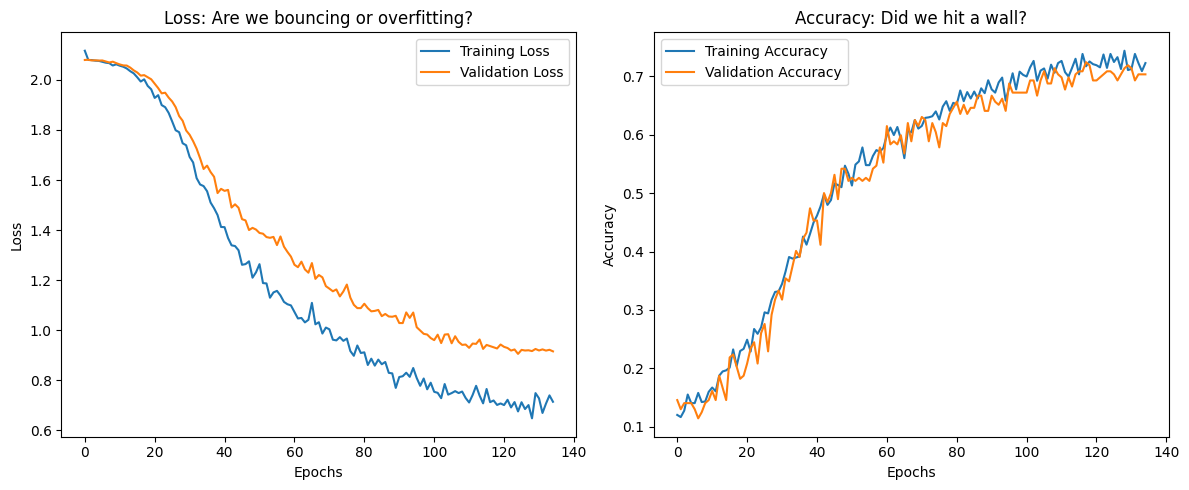

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss: Are we bouncing or overfitting?')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy: Did we hit a wall?')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install --upgrade setuptools

In [8]:
pip install --upgrade setuptools

Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install setuptools


In [8]:
!pip install tensorflow-hub

In [5]:
pip install --upgrade tensorflow-hub

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install setuptools==69.5.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 7.6 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install --upgrade tensorflow-hub

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install tensorflow-io


  Using cached tensorflow_io_gcs_filesystem-0.37.1-cp310-cp310-macosx_12_0_arm64.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 1.9 MB/s  0:00:16m0:00:0100:01
Using cached tensorflow_io_gcs_filesystem-0.37.1-cp310-cp310-macosx_12_0_arm64.whl (3.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow-io]0m [tensorflow-io]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import librosa
import soundfile as sf

source_dir = "Augmented_Data"
target_dir = "YAMNet_Data"

print("Converting dataset to 16kHz for YAMNet...")

for chord in os.listdir(source_dir):
    chord_path = os.path.join(source_dir, chord)
    
    # Skip hidden Mac files like .DS_Store
    if not os.path.isdir(chord_path):
        continue
        
    target_chord_path = os.path.join(target_dir, chord)
    os.makedirs(target_chord_path, exist_ok=True)
    
    for file in os.listdir(chord_path):
        if not file.endswith('.wav'):
            continue
            
        file_path = os.path.join(chord_path, file)
        target_file_path = os.path.join(target_chord_path, file)
        
        # librosa automatically resamples to the sr we request!
        audio, sr = librosa.load(file_path, sr=16000)
        
        # Save the 16kHz file
        sf.write(target_file_path, audio, 16000)

print(f"Done! Your 16kHz files are safely in the '{target_dir}' folder.")

Converting dataset to 16kHz for YAMNet...
Done! Your 16kHz files are safely in the 'YAMNet_Data' folder.


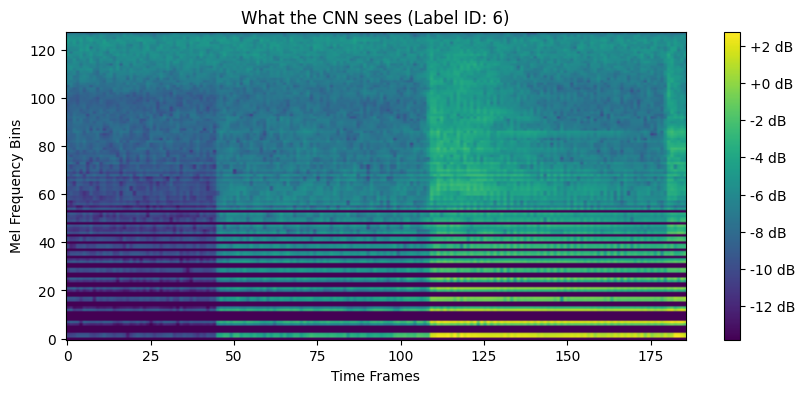

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pull exactly one batch from your training dataset
for waveforms, labels in train_spectrogram_ds.take(1):
    # Grab the very first spectrogram in the batch
    sample_spectrogram = waveforms[0].numpy()
    sample_label = labels[0].numpy()
    break

# 2. Plot the visual representation of the math
plt.figure(figsize=(10, 4))
# We squeeze out the extra channel dimension for plotting
plt.imshow(np.squeeze(sample_spectrogram).T, aspect='auto', origin='lower', cmap='viridis')
plt.title(f"What the CNN sees (Label ID: {sample_label})")
plt.colorbar(format='%+2.0f dB')
plt.ylabel('Mel Frequency Bins')
plt.xlabel('Time Frames')
plt.show()

